# Load Data

In [17]:
TABLE = "price_features"
CALENDAR = "no_calendar"

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [19]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [20]:
df = pull_calendar_table(
    table_name = TABLE,
    calendar = CALENDAR
)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table


In [21]:
table_count = 0
graph_count = 0
matrix_count = 0

# Creating Daily Return Correlation Matrices

Matrix 1:


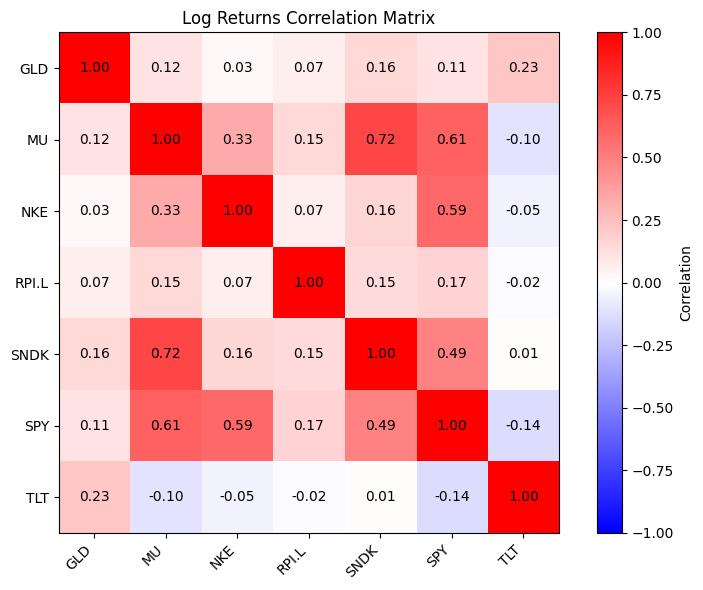

Matrix 2:


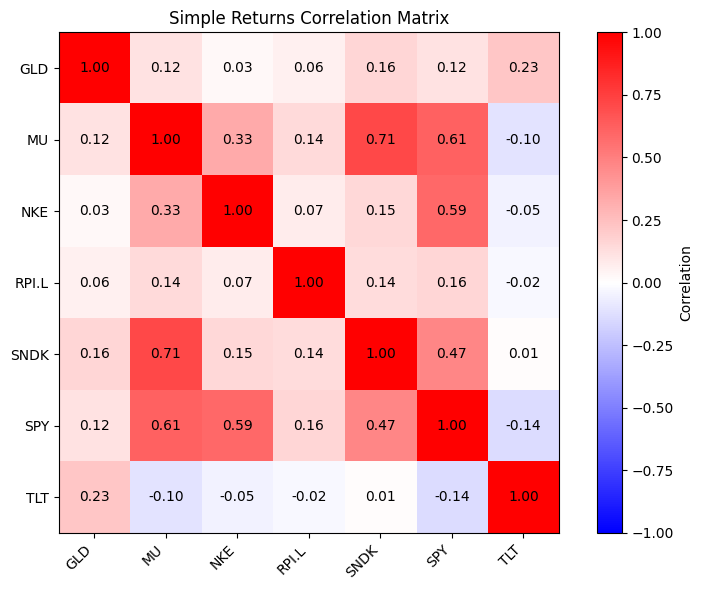

Matrix 3:


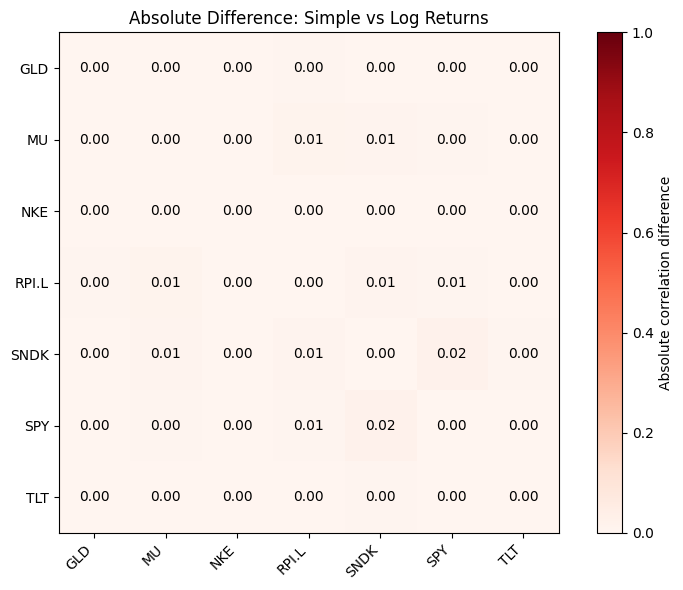

In [22]:
import matplotlib.pyplot as plt

df_1 = df.copy()

date = "date"
ticker = "ticker"

log_returns = f"log_return_{CALENDAR}"
simple_returns = f"daily_return_{CALENDAR}"



log_returns_df = df_1.pivot(
    index=date,
    columns=ticker,
    values=log_returns
)

log_corr_matrix = log_returns_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

plt.imshow(
    log_corr_matrix,
    cmap="bwr",
    vmin=-1,
    vmax=1
)

plt.title("Log Returns Correlation Matrix")

plt.xticks(
    range(len(log_corr_matrix.columns)),
    log_corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(log_corr_matrix.index)),
    log_corr_matrix.index
)

for i in range(len(log_corr_matrix.index)):
    for j in range(len(log_corr_matrix.columns)):
        value = log_corr_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Correlation")
plt.tight_layout()

matrix_count += 1
print(f"Matrix {matrix_count}:")

plt.show()



simple_returns_df = df_1.pivot(
    index=date,
    columns=ticker,
    values=simple_returns
)

simple_corr_matrix = simple_returns_df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

plt.imshow(
    simple_corr_matrix,
    cmap="bwr",
    vmin=-1,
    vmax=1
)

plt.title("Simple Returns Correlation Matrix")

plt.xticks(
    range(len(simple_corr_matrix.columns)),
    simple_corr_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(simple_corr_matrix.index)),
    simple_corr_matrix.index
)

for i in range(len(simple_corr_matrix.index)):
    for j in range(len(simple_corr_matrix.columns)):
        value = simple_corr_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Correlation")
plt.tight_layout()

matrix_count += 1
print(f"Matrix {matrix_count}:")

plt.show()


# -----------------
# Difference matrix
# -----------------

diff = (log_corr_matrix - simple_corr_matrix).abs()

plt.figure(figsize=(8, 6))

plt.imshow(
    diff,
    cmap="Reds",
    vmin=0,
    vmax=1
)

plt.title("Absolute Difference: Simple vs Log Returns")

plt.xticks(
    range(len(diff.columns)),
    diff.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(diff.index)),
    diff.index
)

for i in range(len(diff.index)):
    for j in range(len(diff.columns)):
        value = diff.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Absolute correlation difference")
plt.tight_layout()

matrix_count += 1
print(f"Matrix {matrix_count}:")

plt.show()

# Considering Later IPO Assets

Matrix 4:


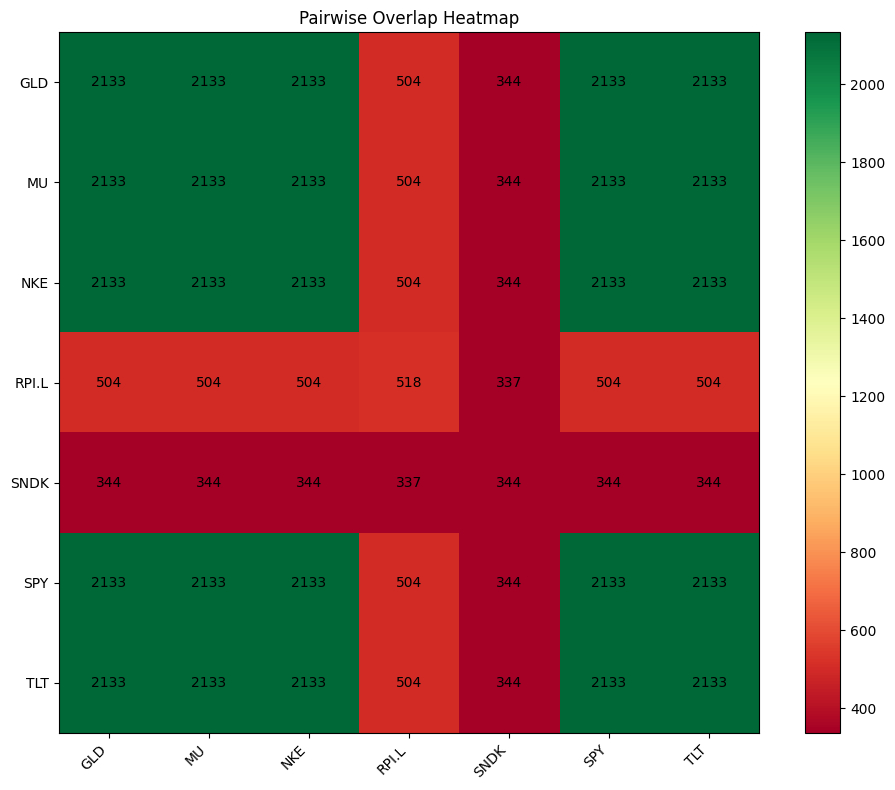

Matrix 5:


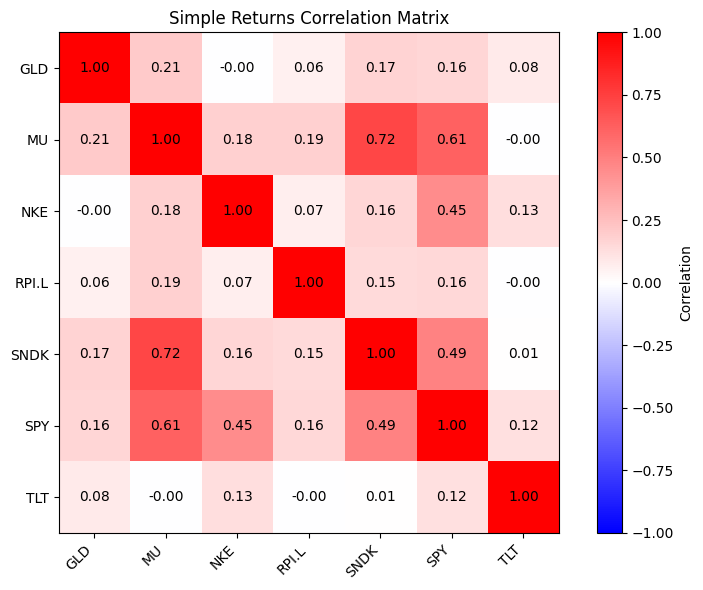

In [23]:
ticker_date_overlap = (
    log_returns_df.notna().astype(int).T
    @ log_returns_df.notna().astype(int)
)

plt.figure(figsize=(10, 8))

plt.imshow(ticker_date_overlap, cmap="RdYlGn")
plt.colorbar()

plt.xticks(
    range(len(ticker_date_overlap.columns)),
    ticker_date_overlap.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(ticker_date_overlap.index)),
    ticker_date_overlap.index
)

plt.title("Pairwise Overlap Heatmap")

for i in range(len(ticker_date_overlap.index)):
    for j in range(len(ticker_date_overlap.columns)):
        value = ticker_date_overlap.iloc[i, j]

        plt.text(
            j, i,
            f"{value}",
            ha="center",
            va="center"
        )

plt.tight_layout()

matrix_count += 1
print(f"Matrix {matrix_count}:")

plt.show()


shared_df = log_returns_df.dropna(axis = 0, how = "any")
shared_corr = shared_df.corr(numeric_only = True)

plt.figure(figsize=(8, 6))

plt.imshow(
    shared_corr,
    cmap="bwr",
    vmin=-1,
    vmax=1
)

plt.title("Simple Returns Correlation Matrix")

plt.xticks(
    range(len(shared_corr.columns)),
    shared_corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(shared_corr.index)),
    shared_corr.index
)

for i in range(len(shared_corr.index)):
    for j in range(len(shared_corr.columns)):
        value = shared_corr.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Correlation")
plt.tight_layout()

matrix_count += 1
print(f"Matrix {matrix_count}:")

plt.show()



# Inspecting Correlation During Volatile Periods

Matrix 6:


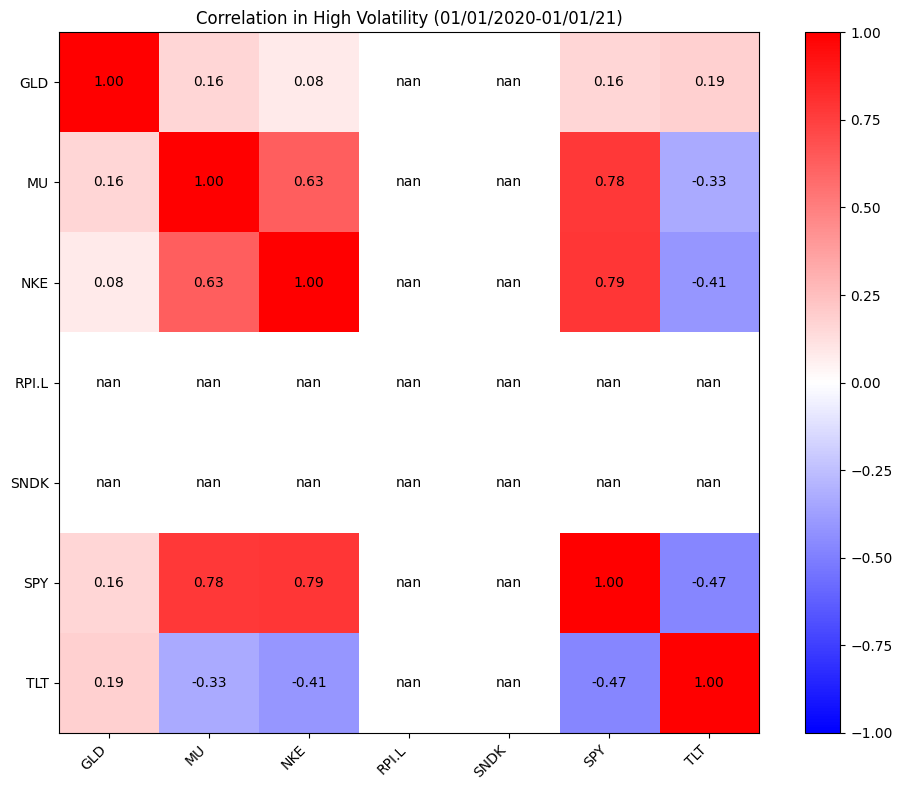

Matrix 7:


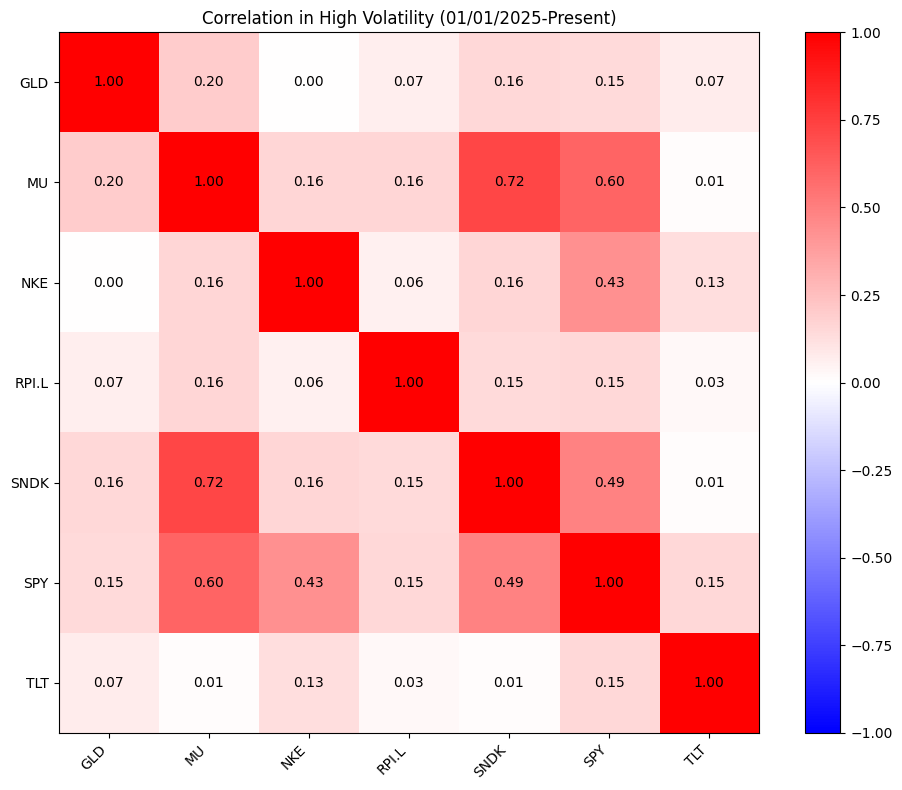

In [24]:
_20to21_df = log_returns_df.loc["2020-01-01":"2021-01-01"]
_20to21_corr = _20to21_df.corr(numeric_only = True)

plt.figure(figsize=(10,8))

plt.imshow(_20to21_corr, cmap="bwr", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(
    range(len(_20to21_corr.columns)), 
    _20to21_corr.columns,
    rotation=45,
    ha="right")

plt.yticks(
    range(len(_20to21_corr.index)),
    _20to21_corr.index
)

plt.title("Correlation in High Volatility (01/01/2020-01/01/21)")

for i in range(len(_20to21_corr.index)):
    for j in range(len(_20to21_corr.columns)):
        value = _20to21_corr.iloc[i,j]

        plt.text(
            j,i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )
    
plt.tight_layout()

matrix_count += 1
print(f"Matrix {matrix_count}:")

plt.show()



_25to_df = log_returns_df.loc["2025-01-01":]
_25to_corr = _25to_df.corr(numeric_only = True)

plt.figure(figsize=(10,8))

plt.imshow(_25to_corr, cmap="bwr", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(
    range(len(_25to_corr.columns)), 
    _25to_corr.columns,
    rotation=45,
    ha="right")

plt.yticks(
    range(len(_25to_corr.index)),
    _25to_corr.index
)

plt.title("Correlation in High Volatility (01/01/2025-Present)")

for i in range(len(_25to_corr.index)):
    for j in range(len(_25to_corr.columns)):
        value = _25to_corr.iloc[i,j]

        plt.text(
            j,i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )
    
plt.tight_layout()

matrix_count += 1
print(f"Matrix {matrix_count}:")

plt.show()


# Indentifying Diversification Patterns

In [35]:
import numpy as np
import pandas as pd

df_2 = df.copy()

date = "date"
ticker = "ticker"
log_returns = f"log_return_{CALENDAR}"

df_2[date] = pd.to_datetime(df_2[date])

log_returns_df = df_2.pivot(
    index=date,
    columns=ticker,
    values=log_returns
).sort_index()


def average_correlation_by_ticker(year_returns):
    corr = year_returns.corr(numeric_only=True)

    return (
        corr.mask(np.eye(len(corr), dtype=bool))
        .mean(axis=1)
    )


yearly_avg_corr = (
    log_returns_df
    .groupby(log_returns_df.index.year)
    .apply(average_correlation_by_ticker)
)

yearly_avg_corr.index.name = "year"
yearly_avg_corr.columns.name = "ticker"

yearly_avg_corr_by_ticker = yearly_avg_corr.T

# Overall average correlation using the full time period
overall_corr = log_returns_df.corr(numeric_only=True)

overall_avg_corr = (
    overall_corr
    .mask(np.eye(len(overall_corr), dtype=bool))
    .mean(axis=1)
)

yearly_avg_corr_by_ticker["Overall Average"] = overall_avg_corr

table_count += 1
print(f"Table {table_count}:")

display(
    yearly_avg_corr_by_ticker
    .reset_index()
    .style
    .format(
        {
            column: "{:.3f}"
            for column in yearly_avg_corr_by_ticker.columns
        },
        na_rep="—"
    )
    .hide(axis="index")
)

Table 2:


ticker,2018,2019,2020,2021,2022,2023,2024,2025,2026,Overall Average
GLD,0.029,-0.039,0.147,0.135,0.184,0.088,0.161,0.034,0.204,0.117
MU,0.209,0.124,0.308,0.227,0.334,0.207,0.180,0.302,0.310,0.306
NKE,0.180,0.103,0.274,0.194,0.397,0.207,0.148,0.184,0.113,0.187
RPI.L,—,—,—,—,—,—,0.077,0.054,0.161,0.097
SNDK,—,—,—,—,—,—,—,0.283,0.269,0.281
SPY,0.231,0.142,0.314,0.263,0.448,0.271,0.275,0.310,0.386,0.306
TLT,-0.109,-0.147,-0.257,-0.015,0.108,0.169,0.056,0.037,0.137,-0.013
